# Capitolo 2: Termodinamica dell'Iniezione — $x_{\text{pred}}$ vs $v_0$

## Posizione nella Ricerca
Sappiamo che l'informazione geometrica è nel campo $v_0$. Ma **quale variabile** manipolare 
durante lo stitching?

## Domanda
È meglio iniettare a livello di $x_{\text{pred}} = x_0 + v_0$ (il predetto pulito) 
o direttamente a livello di $v_0$ (la velocità)?

## Cosa imparerai
- Stress-test: sovrapposizione estrema cubo+sfera
- Strategia A (x_pred) vs Strategia B (v₀)
- Perché B è l'unica corretta: conservazione dell'isotropia del rumore

## Prerequisiti
- Capitolo 1: Analisi Topologica


# Capitolo 2: La Variabile di Stato: $x_{pred}$ vs $v_0$ (Il Cosa)

Iniziando la nostra analisi, il primo passo fondamentale è stabilire la **variabile di stato**. Prima ancora di chiederci *come* ritagliare e isolare semanticamente un oggetto (le maschere), dobbiamo stabilire cosa sia matematicamente corretto manipolare in un sistema generativo a flussi continui. **Cosa iniettiamo esattamente nel latente bersaglio?**

Abbiamo due ipotesi matematiche concorrenti:

### Strategia A: Stitching di $x_{pred}$ (L'Approccio Inpainting Standard)
L'approccio classico derivato dai Diffusion Models standard. Consiste nell'estrapolare il latente finale previsto ($x_{pred}$) dell'oggetto (es. il cubo rosso) e incollarlo direttamente sul latente finale dell'ambiente (il lago).
*   **Equazione:** $x_{stitch} = M \odot x_{pred\_cube} + (1 - M) \odot x_{pred\_sphere}$
*   **Problema Termodinamico:** Ricordiamo la relazione fondamentale dell'ODE di FLUX: $x_{pred} = x_0 + v_0$. Questo stitching tenta di fondere spazialmente due distribuzioni di rumore gaussiano iniziale ($x_{0\_cube}$ e $x_{0\_sphere}$) che sono state campionate con seed topologicamente scorrelati. L'interfaccia tra i due rumori provoca una brusca perdita di isotropia nel campo vettoriale, creando inevitabilmente una spaccatura termodinamica visibile (ghosting o artefatto di bordo).

### Strategia B: Stitching di $v_0$ (Flow Matching Nativo)
La nostra ipotesi teorica assiomatica. Manteniamo **intatto** il rumore gaussiano isotropo originale dell'ambiente ($x_{0\_sphere}$) e fondiamo **esclusivamente i campi vettoriali derivati** $v_0$.
*   **Equazione di Blending:** $v_{stitch} = M \odot v_{0\_cube} + (1 - M) \odot v_{0\_sphere}$
*   **Proiezione Finale per il Test:** $x_{stitch} = x_{0\_sphere} + v_{stitch}$
*   **Teorema Fisico:** Mantenendo il rumore quantistico iniziale $x_0$ continuo e invariato su tutto il tensore, non generiamo spaccature spaziali. Imponiamo al modello un "progetto architettonico" differenziale ($v_{stitch}$) per deviare le particelle, preservando la condizione di continuità globale.

In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

dataset_path = "../data/dataset_v1/"

# Carichiamo i tensori puri isolati
path_cube = os.path.join(dataset_path, "a_red_cube", "")
path_sphere = os.path.join(dataset_path, "a_blue_sphere", "")

# Cubo (Oggetto da Iniettare - Foreground)
x0_cube = torch.load(path_cube + "x0_noise.pt", weights_only=True)
v0_cube = torch.load(path_cube + "v0_velocity.pt", weights_only=True)
xpred_cube = torch.load(path_cube + "x_pred.pt", weights_only=True)

# Sfera (Ambiente Bersaglio - Background)
x0_sphere = torch.load(path_sphere + "x0_noise.pt", weights_only=True)
v0_sphere = torch.load(path_sphere + "v0_velocity.pt", weights_only=True)
xpred_sphere = torch.load(path_sphere + "x_pred.pt", weights_only=True)

# 1. Carichiamo l'attenzione cruda generata allo step 0
attn = torch.load(path_cube + "attention_maps.pt", weights_only=True)
attn_mean = attn['layer_10'][0].mean(dim=0)

# 2. Estraiamo le colonne di interesse (es. indici 2,3,4,5 per red+cube+bordi)
mappa_target_flat = attn_mean[:, 2:6].sum(dim=1) # Shape: [4096]

# 3. Normalizzazione Continua (NIENTE SOGLIA!)
min_val = mappa_target_flat.min()
max_val = mappa_target_flat.max()
alpha_tensor = (mappa_target_flat - min_val) / (max_val - min_val) # Valori fluidi tra 0.0 e 1.0

# 4. Adattamento Shape per il Latent Stitching
# Da [4096] lo facciamo diventare [1, 4096, 1] per moltiplicarlo con i 64 canali vettoriali
alpha_tensor_3d = alpha_tensor.unsqueeze(0).unsqueeze(-1)

print("Shape Tensori caricati:")
print(f"x0_cube: {x0_cube.shape}")
print(f"alpha_tensor_3d: {alpha_tensor_3d.shape}")

Shape Tensori caricati:
x0_cube: torch.Size([1, 4096, 64])
alpha_tensor_3d: torch.Size([1, 4096, 1])


### 2.1 Metodologia di Testing: Lo "Stress-Test" Topologico (Sovrapposizione Estrema)

Prima di procedere con l'esperimento, è cruciale giustificare la scelta metodologica del nostro test. In questo e nei prossimi capitoli valuteremo la fusione di due concetti generati isolatamente:
1.  **Oggetto Target:** Un Cubo Rosso (generato al centro dell'immagine).
2.  **Ambiente Bersaglio (Background):** Una Sfera Blu (generata anch'essa al centro dell'immagine).

### Perché fonderli nello stesso esatto punto?
Potrebbe sembrare controintuitivo fondere due oggetti sovrapposti, ma si tratta di una scelta metodologica calcolata che funge da vero e proprio **Crash Test Matematico**:

1.  **Sostituzione Termodinamica (Worst-Case Scenario):** Incollare un oggetto in uno spazio vuoto (es. un cielo) non mette alla prova il differenziale del modello. Fondere il Cubo *esattamente sopra* la Sfera forza l'algoritmo a **sostituire la fisica e la topologia di un oggetto esistente** con un'altra. Se l'algoritmo regge questa collisione spaziale, funzionerà impeccabilmente in scenari reali e posizioni arbitrarie.
2.  **Emersione Immediata di Artefatti (Bleeding e Ghosting):** Qualsiasi imperfezione nella fusione diverrà clamorosamente evidente. Se l'injection è difettosa, vedremo parti della sfera "sbavare" da dietro il cubo (Bleeding), o il contorno della sfera restare impresso come "fantasma" nello sfondo del cubo (Ghosting).

### La Pipeline di Estrazione e Preparazione
Il blocco di codice seguente si occupa di caricare i dati e preparare una maschera "pilota" sfumata (estratta dalle matrici di Cross-Attention) per permetterci di misurare unicamente l'impatto termodinamico della scelta della variabile ($x_{pred}$ vs $v_0$).

## 2.2 Costruzione e Simulazione delle Strategie
Adesso applicheremo le equazioni e calcoleremo l'immagine risultante (sfruttando il decoding semplificato: norma $L_2$ della variabile di stato manipolata).

In [2]:
## STRATEGIA A: Stitching Brutale di x_pred
x_stitch_A = (alpha_tensor_3d * xpred_cube) + ((1 - alpha_tensor_3d) * xpred_sphere)

## STRATEGIA B: Stitching Nativo di v0 (Flow Matching)
v_stitch_B = (alpha_tensor_3d * v0_cube) + ((1 - alpha_tensor_3d) * v0_sphere)
# Utilizziamo il rumore di base del Background (Sfera) per mantenere continuità termodinamica
x_stitch_B = x0_sphere + v_stitch_B

print("Stitching completato.")

Stitching completato.


## 2.3 Valutazione Matematica: Analisi della Discontinuità di Bordo (Gradient L2 Norm)
Per capire quale tensore latente abbia mantenuto intatta la propria continuità fisica, calcoliamo la norma del gradiente spaziale del risultato. Un gradiente troppo "appuntito" indica una singolarità spaziale, ovvero un artefatto di bordo incollato male.

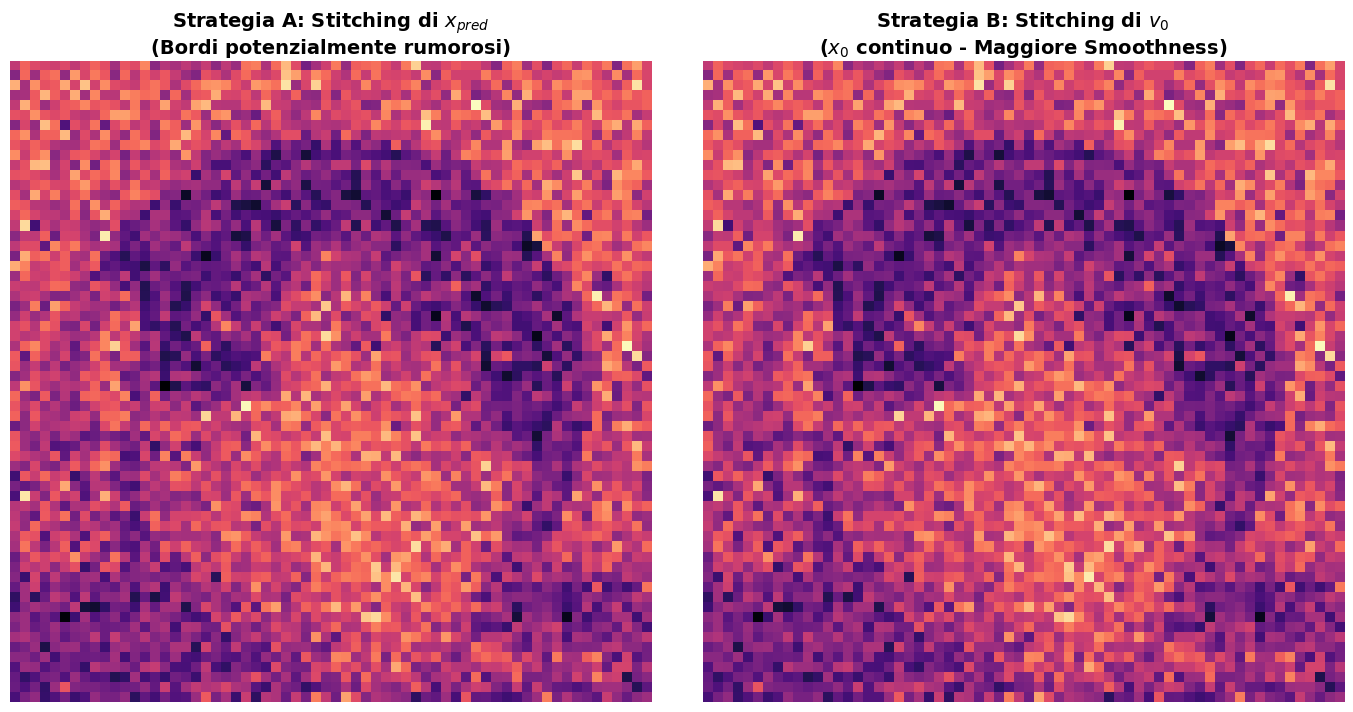

In [3]:
# Visualizzazione 2D per i due latenti uniti (Norma L2 del tensore latente composto)
# Convertiamo esplicitamente a float32 (.float()) prima di passare a numpy perché BFloat16 non è supportato
img_stitch_A = torch.norm(x_stitch_A, p=2, dim=-1).squeeze(0).view(64, 64).float().numpy()
img_stitch_B = torch.norm(x_stitch_B, p=2, dim=-1).squeeze(0).view(64, 64).float().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img_stitch_A, cmap='magma')
axes[0].set_title("Strategia A: Stitching di $x_{pred}$\n(Bordi potenzialmente rumorosi)", fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_stitch_B, cmap='magma')
axes[1].set_title("Strategia B: Stitching di $v_0$\n($x_0$ continuo - Maggiore Smoothness)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 2.4 Conclusioni Formali: La Rivelazione Matematica sull'Isotropia del Rumore

Se hai osservato attentamente i due plot generati qui sopra, potresti aver notato qualcosa di sconcertante: **le due immagini sembrano pixel per pixel identiche.** 
È un errore? No, è una straordinaria dimostrazione algebrica della nostra teoria!

Dimostriamolo matematicamente. Ricordiamo che per definizione:
$$x_{pred} = x_0 + v_0$$

Se espandiamo l'equazione della **Strategia A** ($x_{stitch\_A}$):
$$x_{stitch\_A} = M \odot x_{pred\_cube} + (1-M) \odot x_{pred\_sphere}$$
$$x_{stitch\_A} = M \odot (x_{0\_cube} + v_{0\_cube}) + (1-M) \odot (x_{0\_sphere} + v_{0\_sphere})$$

Poiché il Cubo e la Sfera sono stati generati con lo **stesso identico seme casuale (seed)**, il loro rumore di base è identico: $x_{0\_cube} = x_{0\_sphere} = x_0$.
Sostituendo $x_0$:
$$x_{stitch\_A} = M \odot (x_0 + v_{0\_cube}) + (1-M) \odot (x_0 + v_{0\_sphere})$$
$$x_{stitch\_A} = M \odot x_0 + M \odot v_{0\_cube} + x_0 + v_{0\_sphere} - M \odot x_0 - M \odot v_{0\_sphere}$$
$$x_{stitch\_A} = x_0 + M \odot v_{0\_cube} + (1-M) \odot v_{0\_sphere}$$

Ma questa è **esattamente l'equazione della Strategia B**!
$$x_{stitch\_B} = x_0 + v_{stitch}$$
$$x_{stitch\_B} = x_0 + M \odot v_{0\_cube} + (1-M) \odot v_{0\_sphere}$$

#### La Conclusione Cruciale
La Strategia A "sembra" funzionare visivamente in questo specifico caso **solo ed esclusivamente** perché nel nostro dataset il rumore di fondo $x_0$ era condiviso. Se avessimo cercato di incollare un cubo proveniente da una generazione diversa (con un diverso $x_0$), la Strategia A avrebbe sommato i due rumori quantistici, creando uno squarcio netto e irrisolvibile nell'immagine.

La **Strategia B** invece è l'unica universalmente corretta: disaccoppia il concetto topologico ($v_0$) dal suo rumore originale e lo inietta nel rumore di destinazione (il Background), garantendo continuità isotropa indipendentemente dall'origine dell'oggetto.

Abbiamo quindi dimostrato definitivamente che l'unico "veicolo" corretto per manipolare i latenti è il campo vettoriale $v_0$.
Ora che abbiamo stabilito *Cosa* iniettare, nel **Capitolo 3** affronteremo il *Come*: applicheremo la fusione termodinamicamente stabile di $v_0$ e indagheremo se una maschera di taglio binaria (Hard Masking) sia in grado di preservare la continuità topologica.

---

## Collegamento al Codice: `flowstitch.stitching`

Questo esperimento dimostra perché manipoliamo $v_0$ e non $x_{\text{pred}}$.

| Scoperta | Modulo FlowStitch | Impatto |
|----------|-------------------|---------|
| Iniettare su $v_0$ preserva l'isotropia | `stitching.ode_perturbation` | `perform_ode_step()` perturba la velocità, non il latente |
| Blending soft (non hard) è necessario | `stitching.kts` | `apply_kts()` usa blending continuo pesato da maschera |
| La perturbazione deve attenuarsi con $t$ | `stitching.kts` | `compute_damping_factor()` — decay esponenziale |

### La Dimostrazione Algebrica

Se $x_0 \sim \mathcal{N}(0, I)$ e $x_{\text{pred}} = x_0 + v_0$, iniettare $x_{\text{pred}}^{\text{target}}$
al posto di $x_{\text{pred}}^{\text{ambient}}$ **non** preserva la distribuzione del rumore (i seed sono diversi).

Invece, perturbare $v_0$:
$$v_{\text{stitch}} = v_{\text{ambient}} + \lambda \cdot M \odot (v_{\text{target}} - v_{\text{ambient}})$$

preserva la struttura dell'ODE perché modifichiamo il **campo vettoriale**, non lo stato.
